---
title: "Week 5 Homework"
subtitle: DS 2023 | Communicating with Data
---

## Overview

This homework explores word frequency and part of speech (POS) across a combined corpus of novels by Jane Austen and Herman Melville. 

## The data set

The dataset is a vocabulary table built from the combined novels of Jane Austen and Herman Melville.

| Column | Description |
|---|---|
| `term_str` | The unique word form, including only unigrams (single words). Often called a **term** or a **type**. All terms are lower-case, including proper nouns. |
| `n` | Number of times the term appears across the corpus. This is the number of **tokens** in the corpus associated with the type. Also known as "term frequency" or **TF**. |
| `p` | The relative frequency of the term in the corpus the word accounts for. This is an estimate of the marginal **probability** of the term.|
| `n_chars` | Number of characters in the word. Also know as term length. |
| `max_pos_group` | Most common part-of-speech category group assigned to this word in the corpus. Codes based on the Penn Treebank system. See below. |
| `stop` | Whether the word is a "stop word", i.e. a high-frequency word that may be excluded from various NLP tasks. $1$ if the word is a stop word, $0$ otherwise. |

**About parts of speech**

Each word was tagged by an NLP tagger and assigned a part-of-speech category drawn from the [Penn Treebank](https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html).

The system used here is a truncated version of the Penn system that groups POS tags into two-letter codes.

Here are the codes that compose the domain of the `max_pos_group` variable: 

|Code | Meaning|
|-----|--------|
|NN| Noun| 
|VB| Verb| 
|JJ| Adjective| 
|RB| Adverb| 
|CD| Cardinal number| 
|IN| Preposition| 
|PR| Pronoun| 
|DT| Determiner| 
|FW| Foreign word| 
|MD| Modal  | 
|CC| Coordinating conjunction| 
|WR| Wh-adverb| 
|PO| Possessive ending| 
|PD| Predeterminer| 
|RP| Particle| 
|WP| Wh-pronoun| 
|WD| Wh-determiner| 
|EX| Existential there| 
|TO| the word _to_ | 

Note that, as a general rule, the **first four** categories identify words that do **semantic work**, while the rest of the words do **grammatical** works.

By semantic work, we mean that the words are **content** words used to reference things in the world, whereas grammatical work refers to words that **connect** words into meaningful sentences.

## Tasks

### Task 0: Load data

0 points 

**Load and inspect the data.**

The data URL is here: 

```
https://virginia.box.com/shared/static/ltrh4n9a2eihpo91tjs3ys53hh4lv0lo.csv
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://virginia.box.com/shared/static/ltrh4n9a2eihpo91tjs3ys53hh4lv0lo.csv"
# keep_default_na=False so blank terms stay strings instead of becoming NaN
vocab = pd.read_csv(url, keep_default_na=False)
vocab.head()

,term_str,n,p,n_chars,max_pos_group,stop
0,0,2,9.713651e-07,1,CD,0
1,1,23,1.117070e-05,1,CD,0
2,10,6,2.914095e-06,2,CD,0
3,100,2,9.713651e-07,3,CD,0
4,1000,2,9.713651e-07,4,CD,0


In [2]:
vocab.info()

<class 'pandas.DataFrame'>
RangeIndex: 40283 entries, 0 to 40282
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   term_str       40283 non-null  str    
 1   n              40283 non-null  int64  
 2   p              40283 non-null  float64
 3   n_chars        40283 non-null  int64  
 4   max_pos_group  40283 non-null  str    
 5   stop           40283 non-null  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 1.8 MB


### Task 1: Term frequency TF

1 point

1. How many unique word forms (`term_str`) are in the vocabulary?
2. What is the most frequent value of `term_str`?
3. How often does it appear, expressed as relative frequency rounded to $2$ decimals?

In [3]:
n_terms = len(vocab)  # one row per term
blank_terms = vocab[vocab['term_str'] == '']
top = vocab.loc[vocab['n'].idxmax()]
n_terms, vocab['term_str'].nunique(), len(blank_terms), top['term_str'], round(top['p'], 2)

(40283, 40282, 2, 'the', np.float64(0.05))

**Answers:**

1. There are **40,283** unique word forms (one per row). Note: two rows have a blank `term_str` in the source file (lengths 3 and 4 — most likely the words "nan" and "null" lost when the CSV was written), so `nunique()` reports 40,282.
2. The most frequent term is **"the"** (109,921 tokens).
3. Its relative frequency is **0.05** (about 5% of all tokens).

### Task 2: Histogram of TF 

1 point

Plot a histogram of `n` using $50$ bins.

What does the plot show?

Note that the resulting plot shows a **frequency of frequencies** &mdash; how many times frequency value occurs.

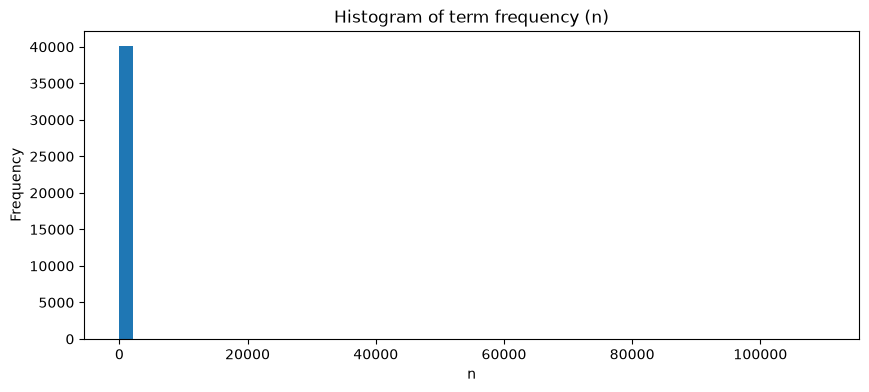

In [4]:
vocab['n'].plot.hist(bins=50, figsize=(10, 4), title="Histogram of term frequency (n)");
plt.xlabel("n");

**Answer:** The distribution is extremely right-skewed. Almost all terms fall into the first bin (they appear only a handful of times), while a tiny number of terms (like "the", "of", "and") occur tens of thousands of times. Because of this long tail, the plot is nearly unreadable on a linear scale — it shows one tall bar and almost nothing else, which is the typical Zipfian shape of word frequencies.

### Task 3: Box plot of log TF

3 points

Now create a histogram and a box plot of the $log_{10}$ value of `n`.

To do this, first create a column `log_n` that is created by `np.log10(vocab['n'])`.

Then plot the new column.

Make the box plot horizontal.

Use $50$ bins for the histogram.

Place the two plots in a single figure with two axes objects in a single columns. 

Have the two plots share the x axis.

Hint: Use `fig, ax = subplots()` with the appropriate arguments.

**Question:** What do these two plots together show that the first plot does not?

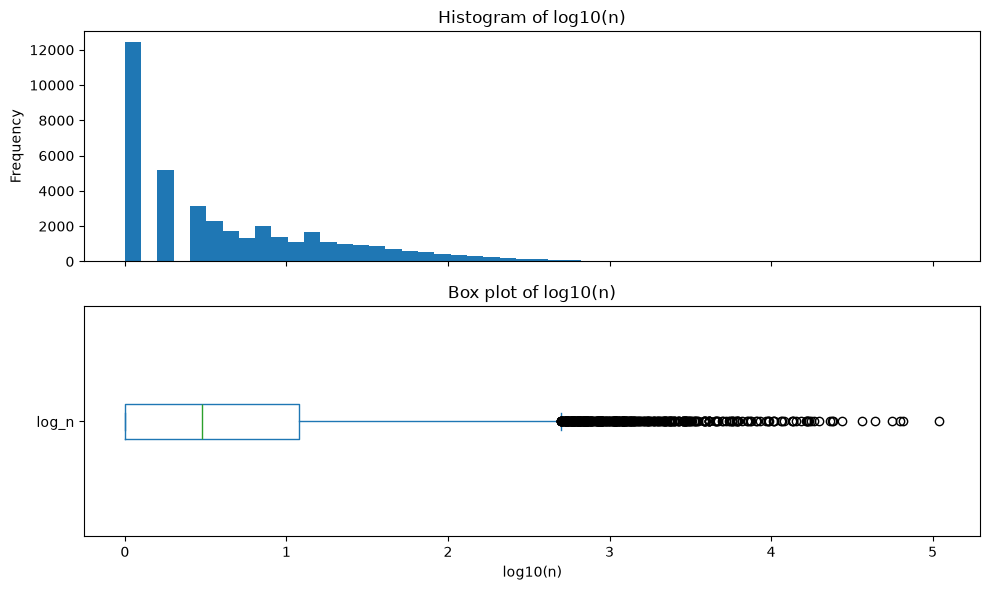

In [5]:
vocab['log_n'] = np.log10(vocab['n'])

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
vocab['log_n'].plot.hist(bins=50, ax=ax[0], title="Histogram of log10(n)")
vocab['log_n'].plot.box(vert=False, ax=ax[1], title="Box plot of log10(n)")
ax[1].set_xlabel("log10(n)")
plt.tight_layout();

**Answer:** On the log scale the structure of the distribution becomes visible. The histogram shows that most terms are rare (the mode is at $\log_{10} n = 0$, i.e. words appearing once — hapax legomena) and the counts decline steadily as frequency grows. The box plot shows that the middle 50% of terms appear between roughly 1 and 12 times (log 0 to ~1.1), and it identifies a long right tail of **outliers** (log values above ~2.7, i.e. more than ~500 occurrences) reaching up to ~5. These outliers are the small set of very high-frequency words that the linear histogram squashed into invisibility.

### Task 4: Frequency of POS

1 point

Using the histogram above as your guide, choose a log value somewhere in the _middle_ of the outlier points.

Call this value `thresh`.

Using this value, get the top 4 POS groups for terms with values above that threshhold.

Call the resulting list of these POS codes `group_a`.

Also get the top 4 POS groups for terms with values below that threshhold.

Call the resulting list of these POS codes `group_b`.

**Question:** Consulting the POS code defintions and notes above, characterize the difference between the two groups.

In [6]:
thresh = 3.5

group_a = vocab.loc[vocab['log_n'] > thresh, 'max_pos_group'].value_counts().head(4).index.tolist()
group_b = vocab.loc[vocab['log_n'] <= thresh, 'max_pos_group'].value_counts().head(4).index.tolist()
group_a, group_b

(['PR', 'IN', 'VB', 'DT'], ['NN', 'VB', 'JJ', 'RB'])

**Answer:** With `thresh = 3.5` (about 3,000+ occurrences), `group_a` = PR, IN, VB, DT and `group_b` = NN, VB, JJ, RB.

Group A (high frequency) is dominated by **grammatical** categories — pronouns, prepositions and determiners (plus verbs, mostly auxiliaries like *was*, *had*, *be*). Group B (lower frequency) consists exactly of the four **semantic/content** categories — nouns, verbs, adjectives and adverbs. So very frequent words do the grammatical "connecting" work, while the bulk of the less frequent vocabulary does the semantic work of referring to things in the world.

### Task 5: Question

1 point

**Question:** Do the most frequent terms belong to the most frequenct POS groups?

**Answer:** No. The most frequent POS groups (by number of distinct terms) are NN, VB, JJ and RB — the content-word categories, which contain tens of thousands of different words. But the most frequent *terms* ("the", "of", "and", "to", "a", ...) belong to small, closed grammatical classes like DT, IN, CC, TO and PR. Those classes have very few members, but each member is used extremely often. So there is an inverse relationship: large POS groups are made of many rare words, and small POS groups are made of a few very frequent words.

### Task 6

3 points

Create a wide table showing projecting POS groups onto axis 1 (the columns) of the dataframe and `log_n` populating its cells (the values).

Include only the set of POS groups that are represents in `group_a` and `group_b`.

Hint: Use `list(set(group_a + group_b))` to get the subset of columns in the wide table.

Plot the wide table as a KDE plot setting the bandwidth to $1$.

Also, set linewidth (`lw`) to $3$ so you can read the legend more clearly.

Use a figure size of $10$ by $5$.

You should see two groups of curves, based on their maxima (peaks). One group, on the left, peaks just above $0$ while the other group, on the right, peaks at just below $4$.

**Questions:** 

1. What POS group has the highest peak in the right-hand group?
2. What POS group has the lowest peak in the left-hand group?
3. Does the answer to the previous question call into question general rule regarding the relationship between frequency on the kind of "work" a word does? You may look up the meaning of the POS group to help you answer this question. Explain your answer in a sentence.

In [7]:
pos_cols = list(set(group_a + group_b))
wide = vocab.pivot(columns='max_pos_group', values='log_n')[pos_cols]
wide.head()

max_pos_group,VB,JJ,RB,NN,DT,IN,PR
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN


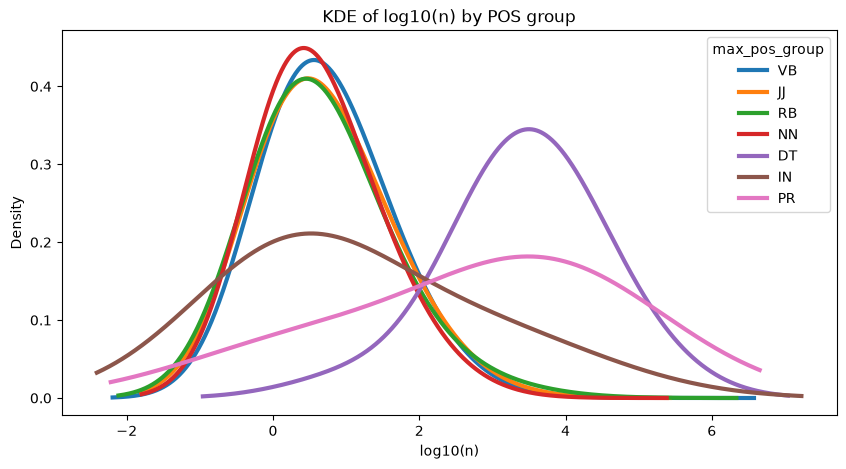

In [8]:
wide.plot.kde(bw_method=1, lw=3, figsize=(10, 5), title="KDE of log10(n) by POS group");
plt.xlabel("log10(n)");

**Answers:**

1. **DT** (determiners) has the highest peak in the right-hand group (the other curve there is PR, pronouns).
2. **IN** (prepositions / subordinating conjunctions) has the lowest peak in the left-hand group.
3. Yes, it qualifies the rule somewhat: IN is a grammatical category, yet its distribution peaks among the *low-frequency* words, because besides a few very common prepositions (*of*, *in*, *that*) the IN group contains many words that appear only once or twice — rare forms like *whichsoever*, *thereabout*, *til*, plus words the tagger mislabeled as IN (e.g. *oratories*, *explodes*). So a grammatical label does not guarantee high frequency; the rule works better in the other direction (very frequent words are grammatical) and is also sensitive to tagging errors.